# ISO 20414:2020 — Test 13: Flow rate, density and walking speed in a corridor

A 2 m x 60 m corridor (area 120 m^2) in three zones (ISO 20414:2020 Table 14). 60/120/240/360/480 occupants give initial densities of 0.5/1.0/2.0/3.0/4.0 p/m^2. Walking speed in zone 2 is measured between line A (x = 20) and line B (x = 40). The expected result is the classic speed-down / flow-hump fundamental diagram.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 30 May 2026, 20:49 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

In [4]:
import json, tempfile
from scenario_builders.iso13_corridor_fd import (
    DENSITY_CASES, build_raw_scenario, CORRIDOR_WKT, measure_zone2)

## Sweep occupant counts / densities

In [5]:
rows = []
for n, rho0 in DENSITY_CASES.items():
    raw = build_raw_scenario(n)
    with tempfile.TemporaryDirectory() as d:
        p = Path(d)
        (p / 'config.json').write_text(json.dumps(raw, indent=2), encoding='utf-8')
        (p / 'geometry.wkt').write_text(CORRIDOR_WKT, encoding='utf-8')
        scenario = load_scenario(str(p))
        r = run_scenario(scenario, seed=42)
        m = measure_zone2(r.trajectory_dataframe(), r.frame_rate)
        m['n_agents'] = n; m['initial_density'] = rho0
        rows.append(m)
        r.cleanup()
fd = pd.DataFrame(rows)
fd

,mean_speed_zone2_m_s,n_speed_samples,peak_density_zone2_p_m2,mean_density_zone2_p_m2,flow_line_b_p_s,specific_flow_line_b_p_m_s,n_agents,initial_density
0,1.919989,41,0.625,0.419860,1.072386,0.536193,60,0.5
1,2.736204,80,1.075,0.748647,1.880952,0.940476,120,1.0
2,3.105167,162,1.950,1.358675,2.543444,1.271722,240,2.0
3,2.002755,241,3.000,2.197902,2.400000,1.200000,360,3.0
4,1.060141,324,4.175,3.061305,2.380251,1.190125,480,4.0


## Fundamental diagram (speed-density and flow-density)

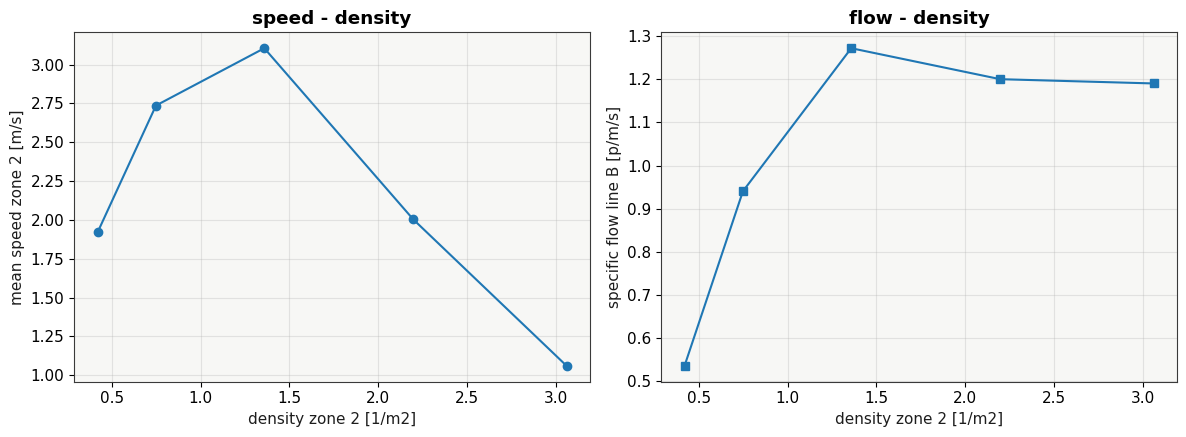

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(fd['mean_density_zone2_p_m2'], fd['mean_speed_zone2_m_s'], 'o-')
ax1.set_xlabel('density zone 2 [1/m2]'); ax1.set_ylabel('mean speed zone 2 [m/s]')
ax1.set_title('speed - density')
ax2.plot(fd['mean_density_zone2_p_m2'], fd['specific_flow_line_b_p_m_s'], 's-')
ax2.set_xlabel('density zone 2 [1/m2]'); ax2.set_ylabel('specific flow line B [p/m/s]')
ax2.set_title('flow - density')
fig.tight_layout(); plt.show()

## Acceptance — FAIL

ISO 20414:2020 Test 13 expects the zone-2 speed-density (and flow-density) relationship to be produced and **compared with the model's underlying assumptions**. Here it contradicts them: every measured mean zone-2 speed (1.9–3.1 m/s) **exceeds the 1.0 m/s free speed assigned to the crowd**, and the curve rises then falls instead of decreasing monotonically. At high density (4 p/m², 480 agents) the corridor visibly jams. The model therefore does **not** demonstrate a valid fundamental diagram and **fails** ISO Test 13.

(The earlier "negative speed-density slope" check passed only as a linear-fit artifact over these non-physical values. CollisionFreeSpeedModel does not reproduce empirical crowd-flow fundamental diagrams.)

In [7]:
free_speed = 1.0
speed = fd['mean_speed_zone2_m_s'].to_numpy()
over = fd.loc[speed > free_speed + 0.05, 'initial_density'].tolist()
print('mean zone-2 speed [m/s]:', [round(float(v), 3) for v in speed])
print(f'assigned free speed v0 = {free_speed} m/s')
verdict = 'FAIL' if over else 'PASS'
print(f'\nRESULT: {verdict} - ISO 20414:2020 Test 13 (corridor fundamental diagram)')
if over:
    print(f'Zone-2 speed exceeds the {free_speed} m/s free speed at densities {over} p/m2,')
    print('non-monotonic in density: the speed-density relationship is non-physical')
    print("and contradicts the model's own assumptions. Documented CFSM limit.")

mean zone-2 speed [m/s]: [1.92, 2.736, 3.105, 2.003, 1.06]
assigned free speed v0 = 1.0 m/s

RESULT: FAIL - ISO 20414:2020 Test 13 (corridor fundamental diagram)
Zone-2 speed exceeds the 1.0 m/s free speed at densities [0.5, 1.0, 2.0, 3.0, 4.0] p/m2,
non-monotonic in density: the speed-density relationship is non-physical
and contradicts the model's own assumptions. Documented CFSM limit.
